# Text-to-Mask Sanity Check — HF Grounding DINO + SAM

This notebook runs a minimal `image + text prompt -> box -> mask` pipeline.

Why this version exists:
- it avoids building the original GroundingDINO repository in editable mode;
- it uses Hugging Face `transformers` for Grounding DINO;
- it uses `segment-anything` for SAM masks.

## 1. Check GPU

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

CUDA available: True
GPU: Tesla T4


'cuda'

## 2. Install dependencies

In [2]:
!pip install -q --upgrade transformers accelerate safetensors
!pip install -q opencv-python matplotlib pillow numpy supervision
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 16.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 3. Download demo image and SAM weights

In [3]:
!mkdir -p data/demo_images outputs/predictions weights

# Demo image with bears
!wget -q https://raw.githubusercontent.com/IDEA-Research/Grounded-Segment-Anything/main/assets/demo1.jpg -O data/demo_images/demo1.jpg

# SAM ViT-B checkpoint
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -O weights/sam_vit_b_01ec64.pth

!ls -lh data/demo_images weights

data/demo_images:
total 368K
-rw-r--r-- 1 root root 368K Jun 10 02:03 demo1.jpg

weights:
total 358M
-rw-r--r-- 1 root root 358M Apr  4  2023 sam_vit_b_01ec64.pth


## 4. Load image

(np.float64(-0.5), np.float64(2067.5), np.float64(1449.5), np.float64(-0.5))

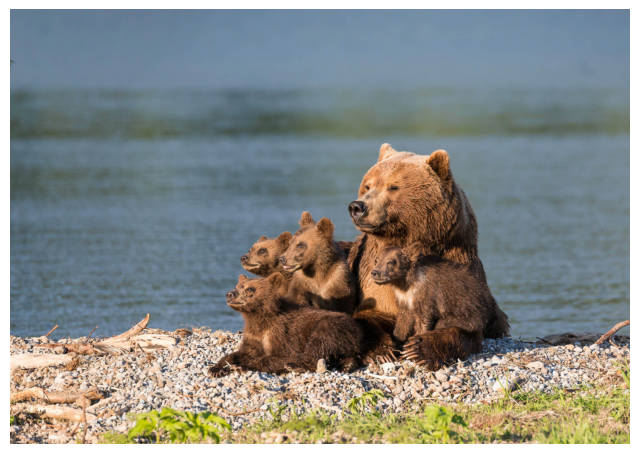

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

IMAGE_PATH = "data/demo_images/demo1.jpg"
image_pil = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(8, 8))
plt.imshow(image_pil)
plt.axis("off")

## 5. Load Grounding DINO from Hugging Face

In [5]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

MODEL_ID = "IDEA-Research/grounding-dino-base"

processor = AutoProcessor.from_pretrained(MODEL_ID)
grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(DEVICE)
grounding_model.eval()

print("Grounding DINO loaded:", MODEL_ID)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.74k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

Grounding DINO loaded: IDEA-Research/grounding-dino-base


## 6. Run text-guided detection

In [12]:
import torch

# IMPORTANT: Grounding DINO expects lowercase text and dot-separated categories.
TEXT_PROMPT = "bear ."
BOX_THRESHOLD = 0.25
TEXT_THRESHOLD = 0.25

inputs = processor(images=image_pil, text=TEXT_PROMPT, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = grounding_model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD,
    target_sizes=[image_pil.size[::-1]],  # (height, width)
)

result = results[0]
boxes = result["boxes"].detach().cpu()
scores = result["scores"].detach().cpu()
labels = result["labels"]

print("num detections:", len(boxes))
print("boxes:", boxes)
print("scores:", scores)
print("labels:", labels)

num detections: 8
boxes: tensor([[ 655.7544,  874.9258, 1190.9637, 1228.0112],
        [ 895.9999,  674.8713, 1155.0734, 1013.1827],
        [1201.0629,  779.7508, 1652.5109, 1201.1335],
        [1118.9962,  444.7359, 1671.9846, 1100.8372],
        [ 766.5496,  741.5343,  944.1451,  901.2395],
        [ 651.2048,  450.7669, 1659.6481, 1219.0673],
        [ 656.6437,  871.9324, 1291.6674, 1223.0226],
        [1113.6116,  450.4948, 1669.5470, 1178.6229]])
scores: tensor([0.4202, 0.4544, 0.4559, 0.4222, 0.4035, 0.3172, 0.2871, 0.2734])
labels: ['bear', 'bear', 'bear', 'bear', 'bear', 'bear', 'bear', 'bear']


In [13]:
from torchvision.ops import nms

NMS_IOU_THRESHOLD = 0.45
MAX_DETECTIONS = 4

if len(boxes) > 0:
    keep = nms(boxes, scores, iou_threshold=NMS_IOU_THRESHOLD)
    keep = keep[:MAX_DETECTIONS]

    boxes = boxes[keep]
    scores = scores[keep]
    labels = [labels[i] for i in keep.tolist()]

print("after NMS:")
print("num detections:", len(boxes))
print("boxes:", boxes)
print("scores:", scores)
print("labels:", labels)

after NMS:
num detections: 4
boxes: tensor([[1201.0629,  779.7508, 1652.5109, 1201.1335],
        [ 895.9999,  674.8713, 1155.0734, 1013.1827],
        [1118.9962,  444.7359, 1671.9846, 1100.8372],
        [ 655.7544,  874.9258, 1190.9637, 1228.0112]])
scores: tensor([0.4559, 0.4544, 0.4222, 0.4202])
labels: ['bear', 'bear', 'bear', 'bear']


## 7. Visualize Grounding DINO boxes

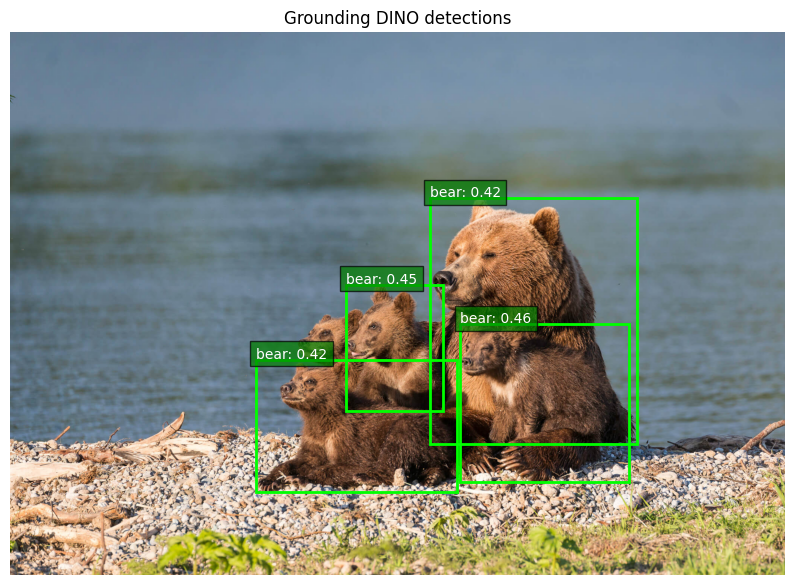

In [14]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image_pil)

for box, score, label in zip(boxes, scores, labels):
    x0, y0, x1, y1 = box.tolist()
    rect = patches.Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        edgecolor="lime",
        facecolor="none",
        linewidth=2,
    )
    ax.add_patch(rect)
    ax.text(
        x0,
        max(y0 - 5, 0),
        f"{label}: {float(score):.2f}",
        color="white",
        fontsize=10,
        bbox=dict(facecolor="green", alpha=0.7),
    )

ax.axis("off")
ax.set_title("Grounding DINO detections")
plt.show()

## 8. Load SAM

In [15]:
from segment_anything import sam_model_registry, SamPredictor

SAM_CHECKPOINT = "weights/sam_vit_b_01ec64.pth"
SAM_MODEL_TYPE = "vit_b"

sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
sam.to(device=DEVICE)

sam_predictor = SamPredictor(sam)

image_np = np.array(image_pil)
sam_predictor.set_image(image_np)

print("SAM loaded")

SAM loaded


## 9. Convert boxes and run SAM

In [16]:
if len(boxes) == 0:
    raise RuntimeError("No boxes detected. Try lowering BOX_THRESHOLD/TEXT_THRESHOLD or use a simpler prompt.")

boxes_torch = boxes.to(DEVICE)

transformed_boxes = sam_predictor.transform.apply_boxes_torch(
    boxes_torch,
    image_np.shape[:2],
).to(DEVICE)

with torch.no_grad():
    masks, mask_scores, _ = sam_predictor.predict_torch(
        point_coords=None,
        point_labels=None,
        boxes=transformed_boxes,
        multimask_output=False,
    )

print("masks:", masks.shape)
print("mask_scores:", mask_scores.detach().cpu())

masks: torch.Size([4, 1, 1450, 2068])
mask_scores: tensor([[0.9759],
        [0.9608],
        [0.9283],
        [0.9399]])


## 10. Visualize final text-to-mask result

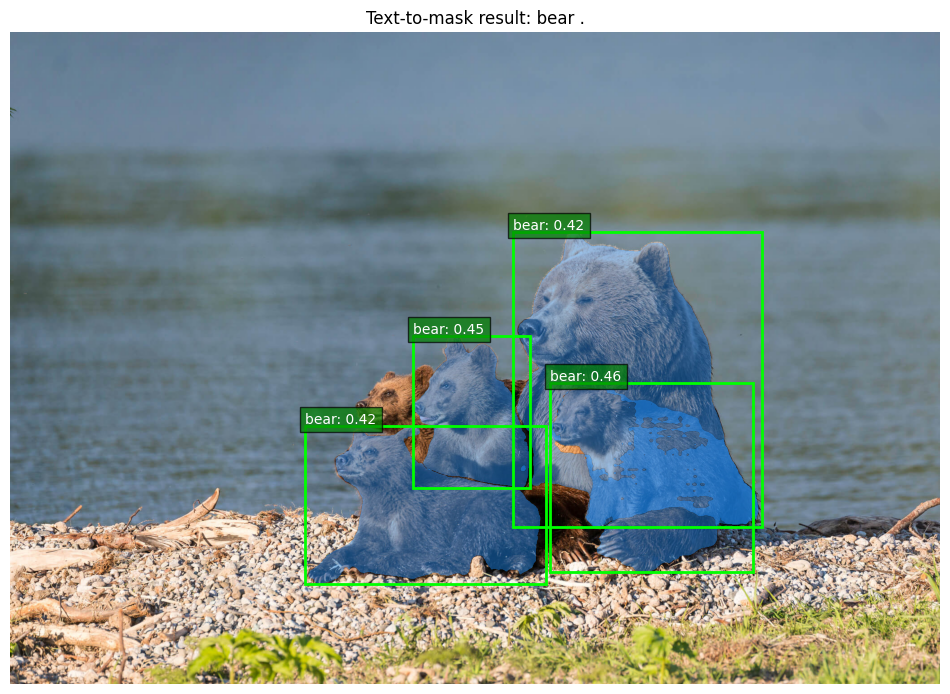

Saved to outputs/predictions/sanity_text_to_mask_hf.png


In [17]:
def show_mask(mask, ax, alpha=0.45):
    mask = mask.detach().cpu().numpy()
    if mask.ndim == 3:
        mask = mask[0]
    color = np.array([30 / 255, 144 / 255, 255 / 255, alpha])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax, label=None):
    x0, y0, x1, y1 = box.detach().cpu().numpy()
    rect = patches.Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        edgecolor="lime",
        facecolor="none",
        linewidth=2,
    )
    ax.add_patch(rect)
    if label is not None:
        ax.text(
            x0,
            max(y0 - 5, 0),
            label,
            color="white",
            fontsize=10,
            bbox=dict(facecolor="green", alpha=0.7),
        )

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(image_pil)

for i, box in enumerate(boxes):
    label = labels[i] if i < len(labels) else None
    score = float(scores[i]) if i < len(scores) else 0.0
    show_box(box, ax, label=f"{label}: {score:.2f}")
    show_mask(masks[i], ax)

ax.axis("off")
ax.set_title(f"Text-to-mask result: {TEXT_PROMPT}")
plt.savefig("outputs/predictions/sanity_text_to_mask_hf.png", bbox_inches="tight", dpi=150)
plt.show()

print("Saved to outputs/predictions/sanity_text_to_mask_hf.png")